In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('..')
from firstpassage.FPTCalculator import *
from compiler.LOTree import *
from scripts.compare_trees import nx_to_vdsp
import random
import perceval as pcvl
import itertools

In [3]:
random.seed(2334)
G = nx.erdos_renyi_graph(7,0.3)
C = list(nx.connected_components(G))
for idx in range(1,len(C)):
    G.add_edge(list(C[idx-1])[0],list(C[idx])[0])
print(G.edges)

[(0, 6), (1, 6), (2, 5), (3, 4), (3, 6), (4, 6), (5, 6)]


In [4]:
vdsp_tree = nx_to_vdsp(nx.minimum_spanning_tree(G), 0)
q = LOTree(0)
# print("before build optimal")
current_optimal_tree, current_loops = build_optimal_linear(vdsp_tree.head,q, False)
fusion_order = current_optimal_tree.get_fusion_order()
get_fp_times(fusion_order, int(current_optimal_tree.circuit.m/2), [0.5,0.66,0.75,0.85,1])

{0.5: 42.00000004578487,
 0.66: 18.3333038341723,
 0.75: 12.790123453458724,
 0.85: 9.116988581179195,
 1: 6.000000008347424}

In [5]:
fusion_order

[(2, 3), (5, 6), (11, 12), (17, 18), (7, 9), (10, 15)]

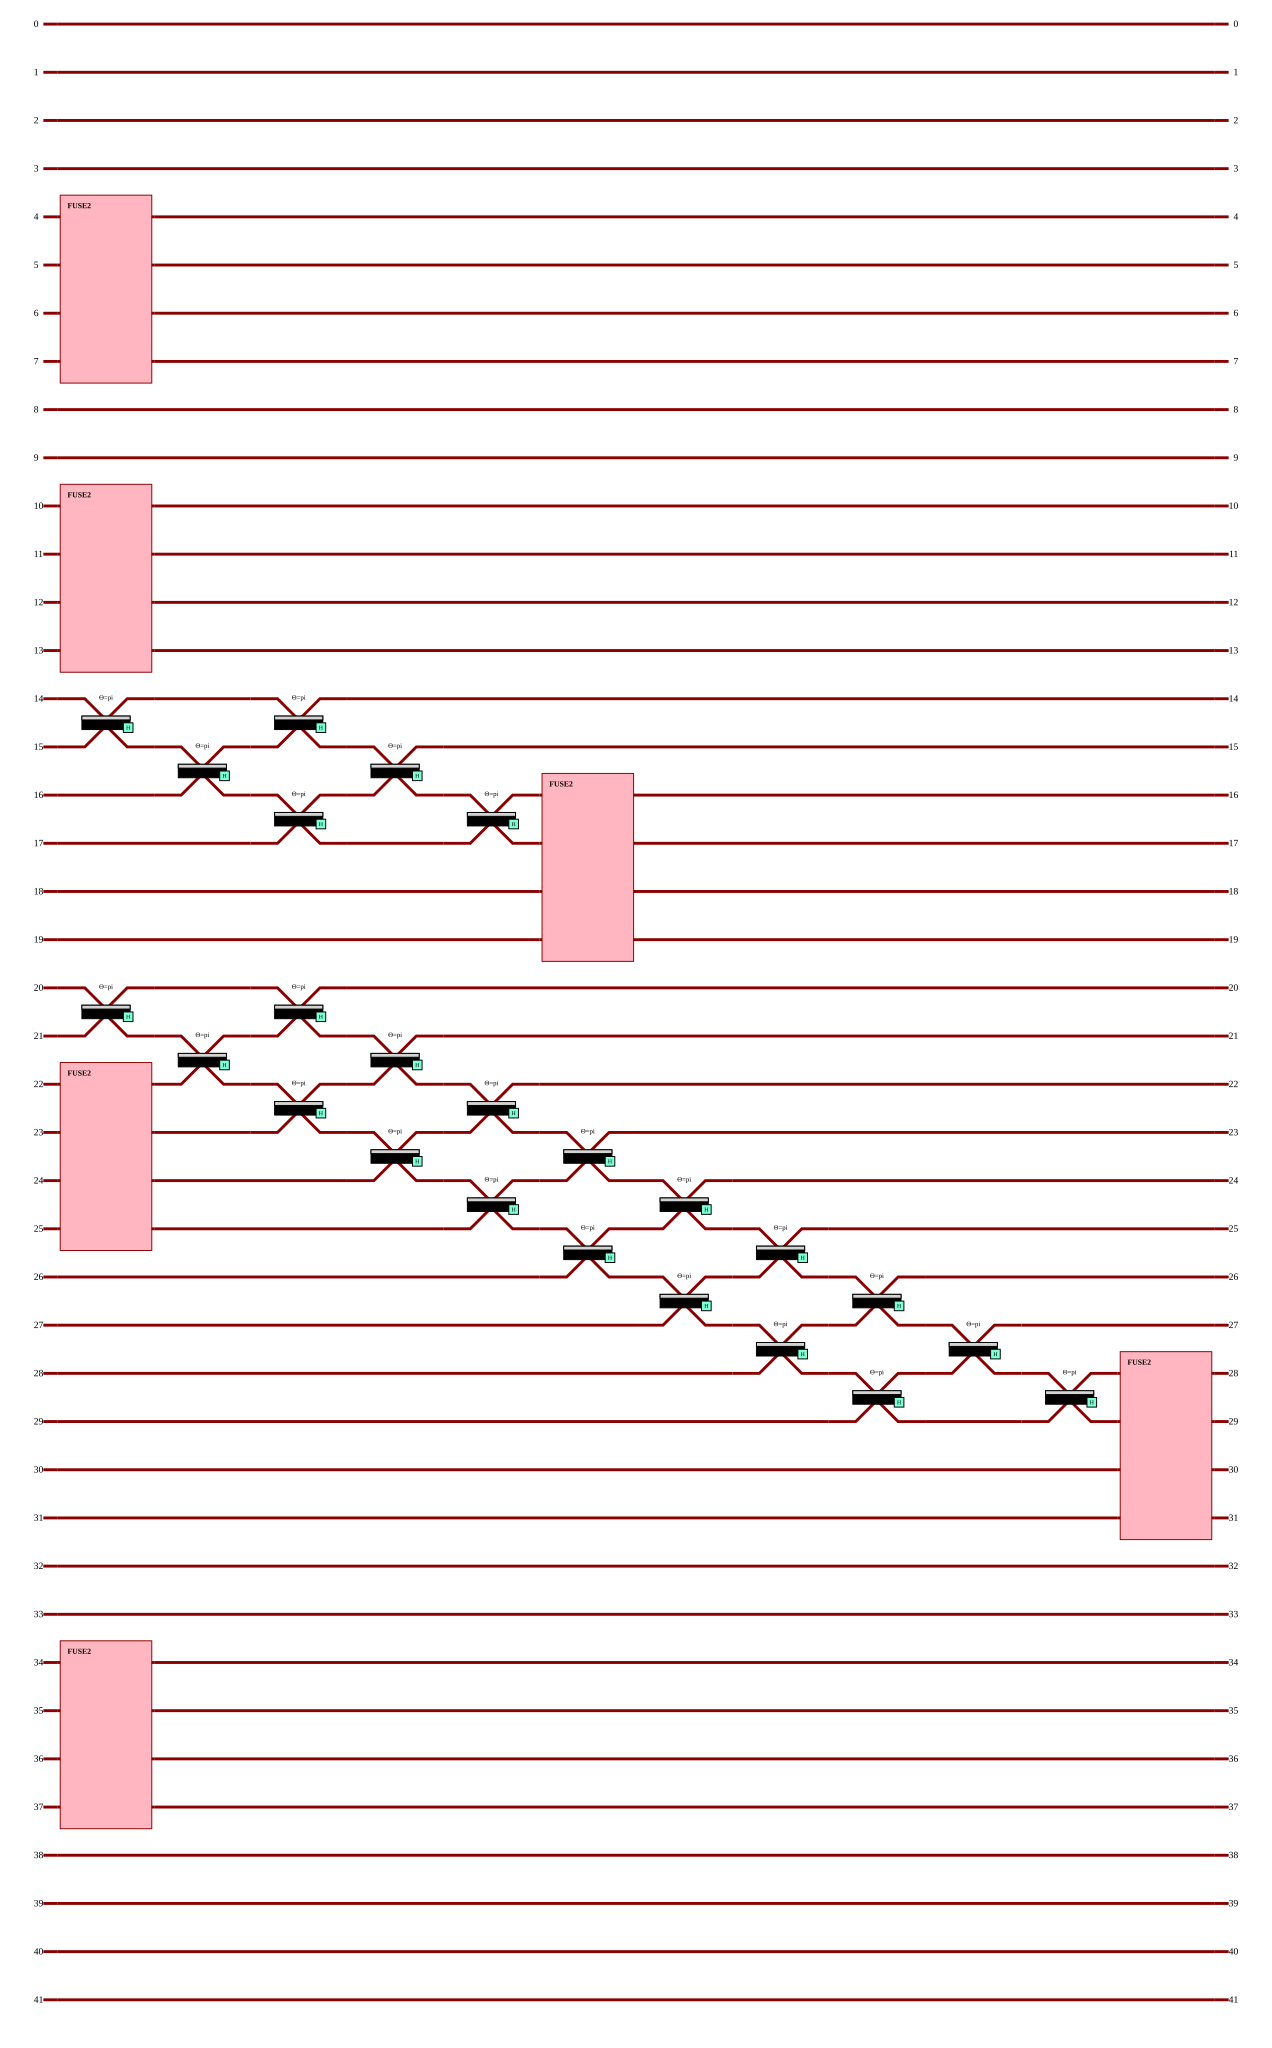

In [10]:
new_lotree = LOTree(0)
f_o = [(2, 3), (5, 6), (11, 12), (17, 18), (7, 9), (10, 15)]
# int((max([v for fusion in fusion_order for v in fusion]) + 3) / 3) * 6
new_lotree.build_from_fusion_order(f_o)
pcvl.pdisplay(new_lotree.circuit)

In [11]:
random_f_order = fusion_order
random.shuffle(random_f_order)
get_fp_times(random_f_order, int(current_optimal_tree.circuit.m/2), [0.5,0.66,0.75,0.85,1])

{0.5: 38.99999999049004,
 0.66: 15.595446887691685,
 0.75: 11.09053498411105,
 0.85: 8.295114947622663,
 1: 5.999999997583013}

In [15]:
random_f_order

[(10, 15), (11, 12), (2, 3), (17, 18), (7, 9), (5, 6)]

In [23]:
def convert_fusion_order(f_order):
    new_f_order = []
    vertex_map = {}
    current_max_vertex = 0
    for v1, v2 in f_order:
        for v in [v1,v2]:
            if not v in vertex_map:
                for i, v_ghz in enumerate(range(int(v/3)*3,(int(v/3)+1)*3)):
                    vertex_map[v_ghz] = current_max_vertex+i
                current_max_vertex += 3
        new_f_order.append((vertex_map[v1],vertex_map[v2]))
    return new_f_order

convert_fusion_order(random_f_order)

[(1, 3), (2, 6), (11, 12), (5, 15), (19, 0), (14, 18)]

initial vertex pos map {0: 0, 1: 2, 2: 4, 3: 6, 4: 8, 5: 10, 6: 12, 7: 14, 8: 16, 9: 18, 10: 20, 11: 22, 12: 24, 13: 26, 14: 28, 15: 30, 16: 32, 17: 34, 18: 36, 19: 38, 20: 40}
sink 2 to 4
updated vertex pos map {0: 0, 1: 4, 2: 2, 3: 6, 4: 8, 5: 10, 6: 12, 7: 14, 8: 16, 9: 18, 10: 20, 11: 22, 12: 24, 13: 26, 14: 28, 15: 30, 16: 32, 17: 34, 18: 36, 19: 38, 20: 40}
sink 2 to 10
updated vertex pos map {0: 0, 1: 2, 2: 10, 3: 4, 4: 6, 5: 8, 6: 12, 7: 14, 8: 16, 9: 18, 10: 20, 11: 22, 12: 24, 13: 26, 14: 28, 15: 30, 16: 32, 17: 34, 18: 36, 19: 38, 20: 40}
sink 8 to 28
updated vertex pos map {0: 0, 1: 2, 2: 8, 3: 4, 4: 6, 5: 28, 6: 10, 7: 12, 8: 14, 9: 16, 10: 18, 11: 20, 12: 22, 13: 24, 14: 26, 15: 30, 16: 32, 17: 34, 18: 36, 19: 38, 20: 40}
sink 0 to 36
updated vertex pos map {0: 36, 1: 0, 2: 6, 3: 2, 4: 4, 5: 26, 6: 8, 7: 10, 8: 12, 9: 14, 10: 16, 11: 18, 12: 20, 13: 22, 14: 24, 15: 28, 16: 30, 17: 32, 18: 34, 19: 38, 20: 40}
sink 24 to 32
updated vertex pos map {0: 36, 1: 0, 2: 6, 3: 2, 4

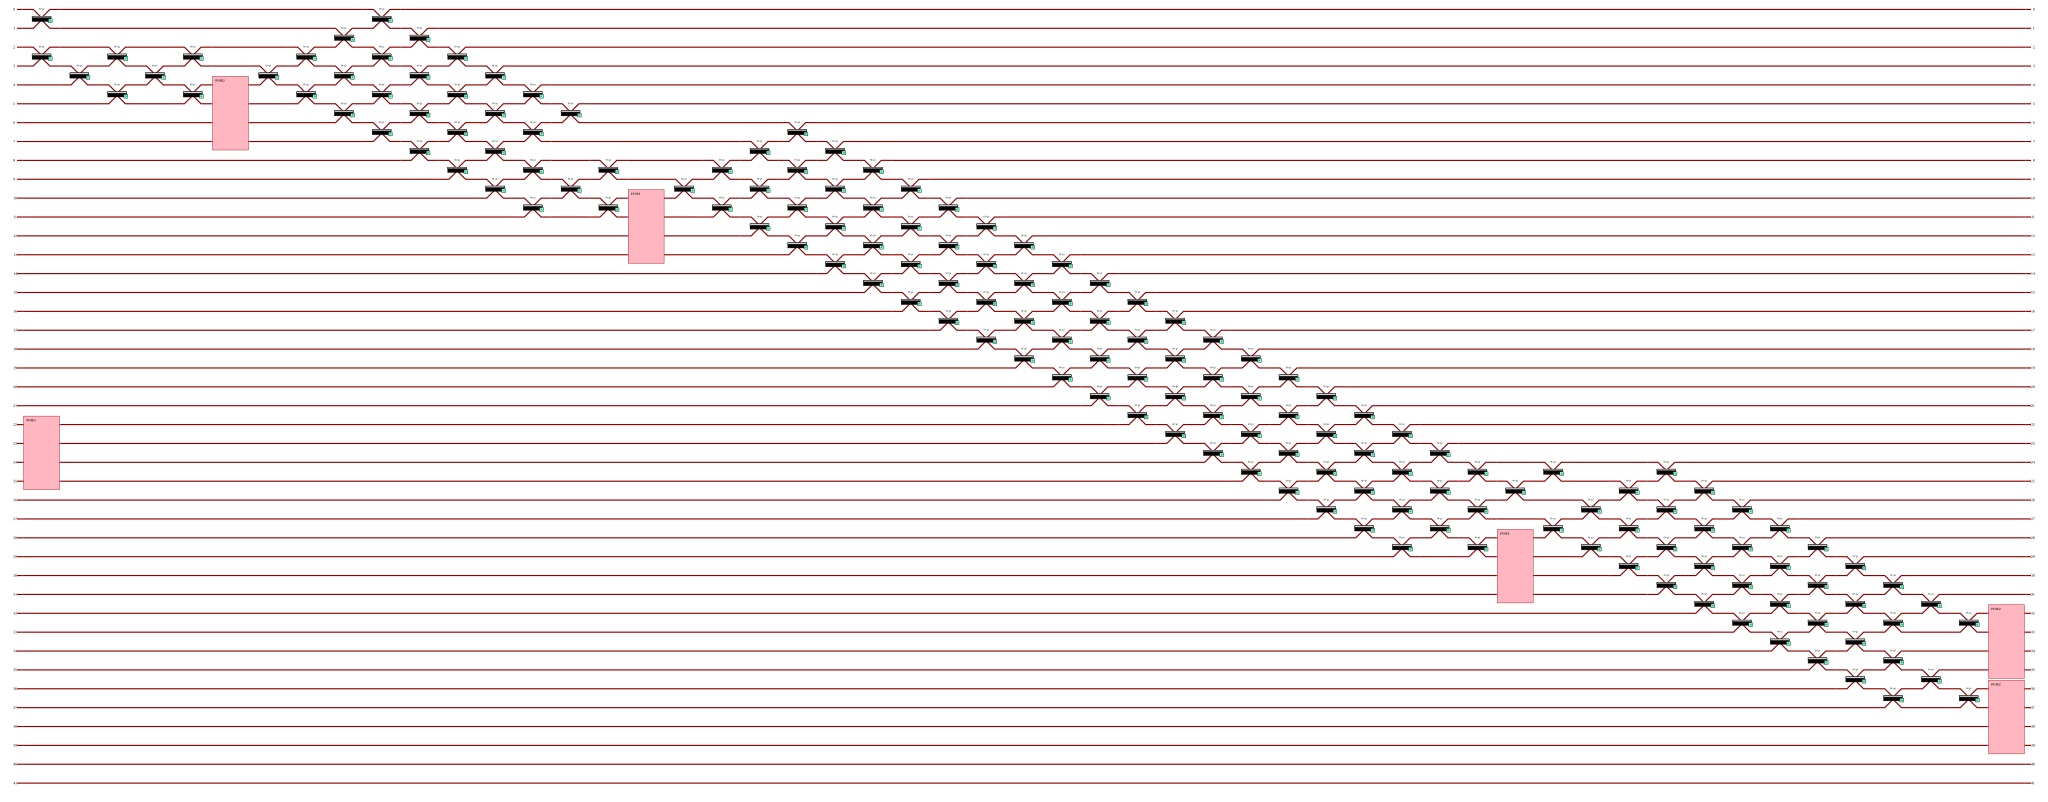

In [22]:
new_lotree2 = LOTree(0)
# int((max([v for fusion in fusion_order for v in fusion]) + 3) / 3) * 6
new_lotree2.build_from_fusion_order(convert_fusion_order(random_f_order))
pcvl.pdisplay(new_lotree2.circuit)

In [14]:
# test_optimal_order = [(2, 3), (5, 6), (11, 12), (17, 18), (22, 24), (31, 36), (32, 33), (14, 15), (26, 27), (4, 9), (25, 30), (19, 21)]
# test_optimal_order = [(4,9),(19,21),(25,30), (14,15), (2,3),(5,6), (22,24), (31,36), (26,27),(11,12),(17,18),(32,33)]
test_optimal_order = [(4,9),(19,21), (22,24),(25,30), (31,36), (14,15), (2,3),(5,6), (26,27),(11,12),(17,18),(32,33)]
get_fp_times(test_optimal_order, int(current_optimal_tree.circuit.m/2), [0.5,0.66,0.75,0.85,1])

{0.5: 234.66666665237267,
 0.66: 46.85809755301273,
 0.75: 27.327822925124245,
 0.85: 18.060158151323666,
 1: 12.000000011930489}

In [19]:
print(random_f_order)

[(2, 3), (10, 15), (17, 18), (11, 12), (5, 6), (7, 9)]


In [27]:
min_times = {0.5: 234.66666665237267,0.66: 46.85809755301273,0.75: 27.327822925124245, 0.85: 18.060158151323666}
min_perm = {0.5: None,0.66: None,0.75: None, 0.85: None}
for perm in itertools.permutations(fusion_order):
    fp_times = get_fp_times(list(perm), int(current_optimal_tree.circuit.m/2), [0.5,0.66,0.75,0.85,1])
    for k,v in min_times.items():
        if fp_times[k] < v:
            min_times[k] = fp_times[k]
            min_perm[k] = perm

In [28]:
min_perm

{0.5: ((2, 3), (17, 18), (5, 6), (11, 12), (10, 15), (7, 9)),
 0.66: ((17, 18), (11, 12), (10, 15), (5, 6), (7, 9), (2, 3)),
 0.75: ((17, 18), (11, 12), (10, 15), (5, 6), (7, 9), (2, 3)),
 0.85: ((17, 18), (11, 12), (10, 15), (5, 6), (7, 9), (2, 3))}

In [29]:
min_times

{0.5: 27.99999999970989,
 0.66: 14.477415446436718,
 0.75: 10.728395043076286,
 0.85: 8.214233556051887}

in dfs for graph with nodes [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20] fusion order [(11, 12), (17, 18), (10, 15), (5, 6), (7, 9), (2, 3)]


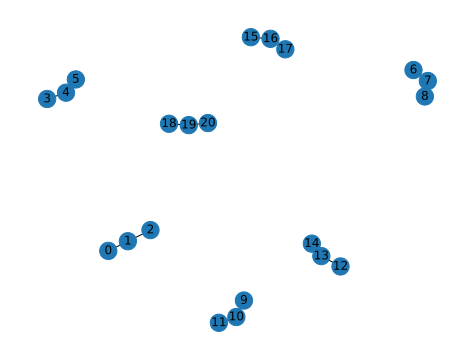

fusion  (11, 12)  success
in dfs for graph with nodes [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 13, 14, 15, 16, 17, 18, 19, 20] fusion order [(11, 12), (17, 18), (10, 15), (5, 6), (7, 9), (2, 3)]


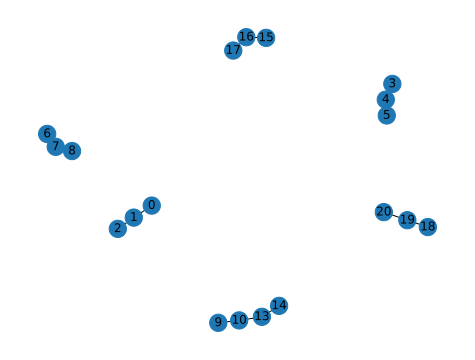

fusion  (17, 18)  success
in dfs for graph with nodes [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 13, 14, 15, 16, 19, 20] fusion order [(11, 12), (17, 18), (10, 15), (5, 6), (7, 9), (2, 3)]


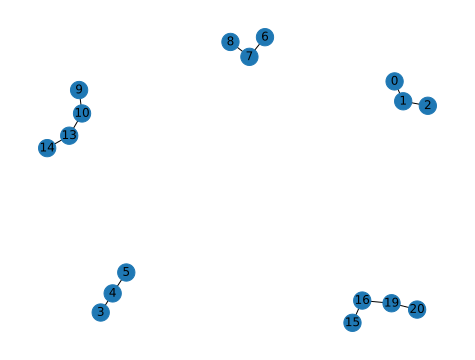

fusion  (10, 15)  success
in dfs for graph with nodes [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 13, 14, 16, 19, 20] fusion order [(11, 12), (17, 18), (10, 15), (5, 6), (7, 9), (2, 3)]


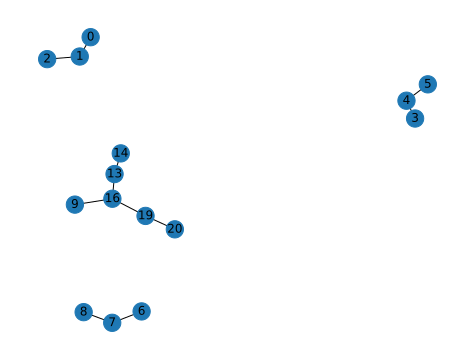

fusion  (5, 6)  success
in dfs for graph with nodes [0, 1, 2, 3, 4, 7, 8, 9, 13, 14, 16, 19, 20] fusion order [(11, 12), (17, 18), (10, 15), (5, 6), (7, 9), (2, 3)]


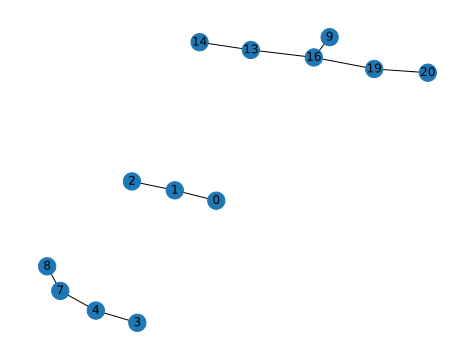

fusion  (7, 9)  success
in dfs for graph with nodes [0, 1, 2, 3, 4, 8, 13, 14, 16, 19, 20] fusion order [(11, 12), (17, 18), (10, 15), (5, 6), (7, 9), (2, 3)]


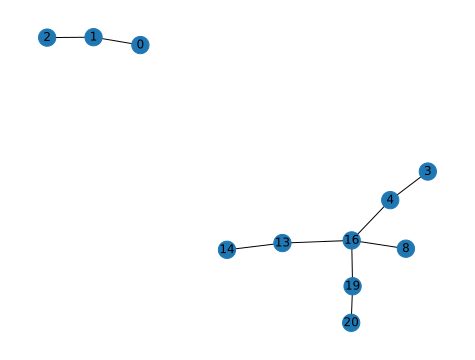

fusion  (2, 3)  success
in dfs for graph with nodes [0, 1, 4, 8, 13, 14, 16, 19, 20] fusion order [(11, 12), (17, 18), (10, 15), (5, 6), (7, 9), (2, 3)]


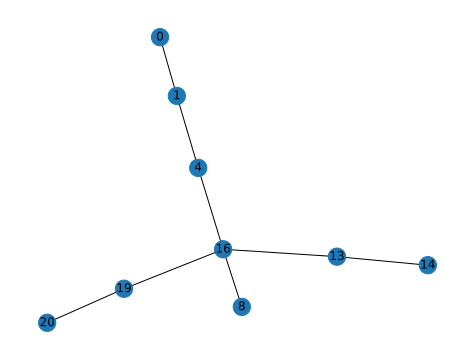

fusion failure  2 3
rebuilding vertex 2
connected components for neighbor 1 : {0, 1}
set initial ghz as  (2, 1, 0)
rebuilding vertex 3
connected components for neighbor 4 : {4, 8, 13, 14, 16, 19, 20}
set initial ghz as  (3, 4, 27) fusing the last with neighbor 4
vertex map: {2: 23, 1: 22, 0: 21, 3: 26, 4: 25}
in dfs for graph with nodes [4, 8, 13, 14, 16, 19, 20, 21, 22, 23, 24, 25, 26] fusion order [(11, 12), (17, 18), (10, 15), (5, 6), (4, 24), (23, 26)]


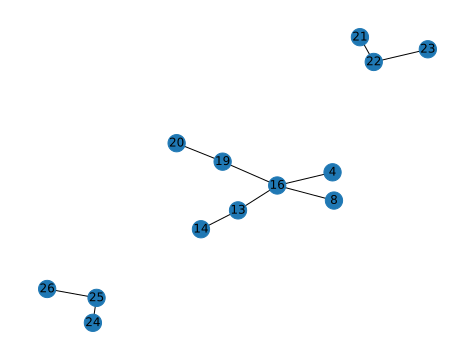

fusion  (4, 24)  success
fusion failure  4 24
rebuilding vertex 4
connected components for neighbor 16 : {8, 13, 14, 16, 19, 20}
set initial ghz as  (4, 16, 30) fusing the last with neighbor 16
rebuilding vertex 24
connected components for neighbor 25 : {25, 26}
set initial ghz as  (24, 25, 26)
vertex map: {4: 29, 16: 28, 24: 32, 25: 31, 26: 30}
fusion failure  7 9
rebuilding vertex 7
connected components for neighbor 8 : {8}
connected components for neighbor 4 : {3, 4}
set initial ghz as  (7, 4, 3)
add singular vertex 8
rebuilding vertex 9
connected components for neighbor 16 : {13, 14, 16, 19, 20}
set initial ghz as  (9, 16, 42) fusing the last with neighbor 16
vertex map: {7: 37, 4: 34, 3: 33, 8: 38, 9: 41, 16: 40}
in dfs for graph with nodes [0, 1, 2, 13, 14, 16, 19, 20, 33, 34, 35, 36, 37, 38, 39, 40, 41] fusion order [(11, 12), (17, 18), (10, 15), (35, 36), (16, 39), (37, 41), (2, 33)]


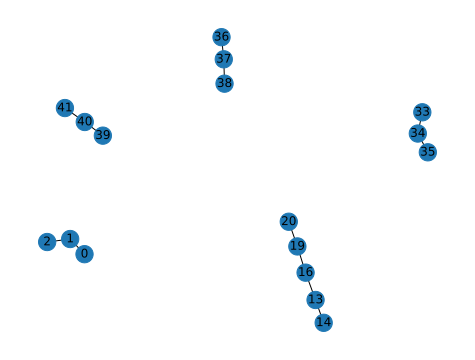

fusion  (35, 36)  success
in dfs for graph with nodes [0, 1, 2, 13, 14, 16, 19, 20, 33, 34, 37, 38, 39, 40, 41] fusion order [(11, 12), (17, 18), (10, 15), (35, 36), (16, 39), (37, 41), (2, 33)]


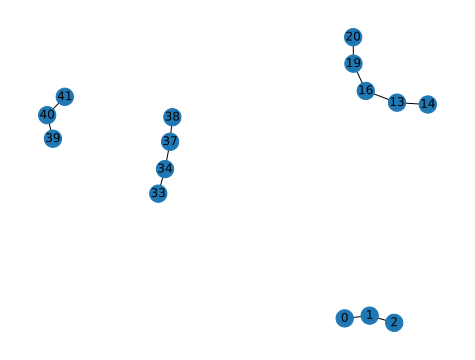

fusion  (16, 39)  success
fusion failure  16 39
rebuilding vertex 16
connected components for neighbor 19 : {19, 20}
set initial ghz as  (16, 19, 20)
rebuilding vertex 39
connected components for neighbor 40 : {40, 41}
set initial ghz as  (39, 40, 41)
vertex map: {16: 46, 19: 43, 20: 42, 13: 49, 14: 50, 39: 53, 40: 52, 41: 51}
fusion failure  35 36
rebuilding vertex 35
connected components for neighbor 34 : {33, 34}
set initial ghz as  (35, 34, 33)
rebuilding vertex 36
connected components for neighbor 37 : {37, 38}
set initial ghz as  (36, 37, 38)
vertex map: {35: 56, 34: 55, 33: 54, 36: 59, 37: 58, 38: 57}
fusion failure  5 6
rebuilding vertex 5
connected components for neighbor 4 : {3, 4}
set initial ghz as  (5, 4, 3)
rebuilding vertex 6
connected components for neighbor 7 : {8, 7}
set initial ghz as  (6, 7, 8)
vertex map: {5: 62, 4: 61, 3: 60, 6: 65, 7: 64, 8: 63}
fusion failure  10 15
rebuilding vertex 10
connected components for neighbor 9 : {9}
connected components for neighbor 

{0.5: 30.999999974396374,
 0.66: 14.477415446436718,
 0.75: 10.728395043076286,
 0.85: 8.214233556051887,
 1: 5.999999994223321}

In [39]:
get_fp_times([ (11, 12), (17, 18),(10, 15), (5, 6), (7, 9), (2, 3)], int(current_optimal_tree.circuit.m/2), [0.5,0.66,0.75,0.85,1], True)

in dfs for graph with nodes [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20] fusion order [(5, 6), (11, 12), (17, 18), (10, 15), (7, 9), (2, 3)]


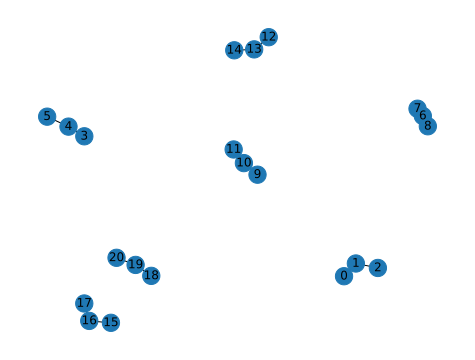

fusion  (5, 6)  success
in dfs for graph with nodes [0, 1, 2, 3, 4, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20] fusion order [(5, 6), (11, 12), (17, 18), (10, 15), (7, 9), (2, 3)]


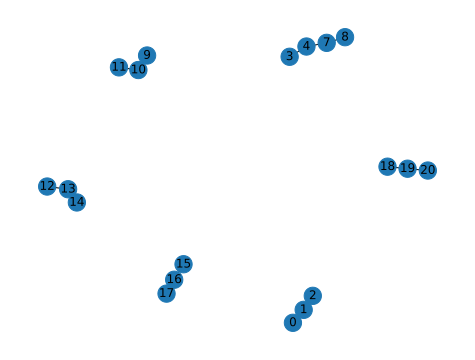

fusion  (11, 12)  success
in dfs for graph with nodes [0, 1, 2, 3, 4, 7, 8, 9, 10, 13, 14, 15, 16, 17, 18, 19, 20] fusion order [(5, 6), (11, 12), (17, 18), (10, 15), (7, 9), (2, 3)]


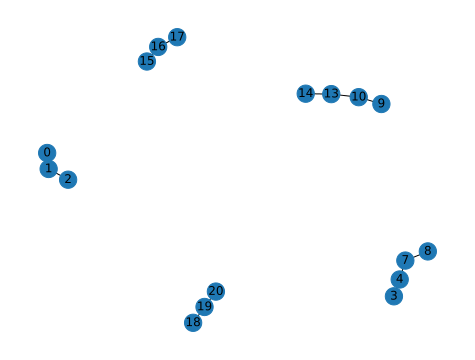

fusion  (17, 18)  success
in dfs for graph with nodes [0, 1, 2, 3, 4, 7, 8, 9, 10, 13, 14, 15, 16, 19, 20] fusion order [(5, 6), (11, 12), (17, 18), (10, 15), (7, 9), (2, 3)]


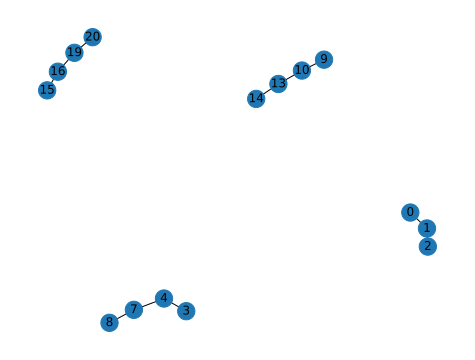

fusion  (10, 15)  success
in dfs for graph with nodes [0, 1, 2, 3, 4, 7, 8, 9, 13, 14, 16, 19, 20] fusion order [(5, 6), (11, 12), (17, 18), (10, 15), (7, 9), (2, 3)]


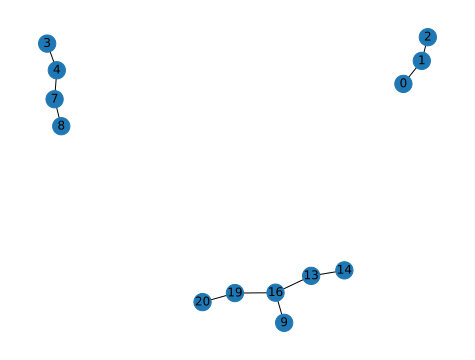

fusion  (7, 9)  success
in dfs for graph with nodes [0, 1, 2, 3, 4, 8, 13, 14, 16, 19, 20] fusion order [(5, 6), (11, 12), (17, 18), (10, 15), (7, 9), (2, 3)]


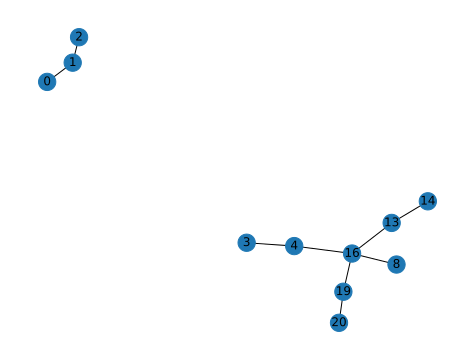

fusion  (2, 3)  success
in dfs for graph with nodes [0, 1, 4, 8, 13, 14, 16, 19, 20] fusion order [(5, 6), (11, 12), (17, 18), (10, 15), (7, 9), (2, 3)]


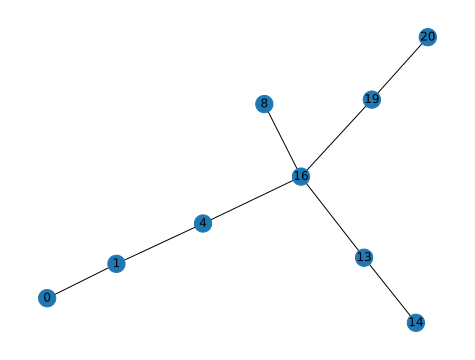

fusion failure  2 3
rebuilding vertex 2
connected components for neighbor 1 : {0, 1}
set initial ghz as  (2, 1, 0)
rebuilding vertex 3
connected components for neighbor 4 : {4, 8, 13, 14, 16, 19, 20}
set initial ghz as  (3, 4, 27) fusing the last with neighbor 4
vertex map: {2: 23, 1: 22, 0: 21, 3: 26, 4: 25}
in dfs for graph with nodes [4, 8, 13, 14, 16, 19, 20, 21, 22, 23, 24, 25, 26] fusion order [(5, 6), (11, 12), (17, 18), (10, 15), (4, 24), (23, 26)]


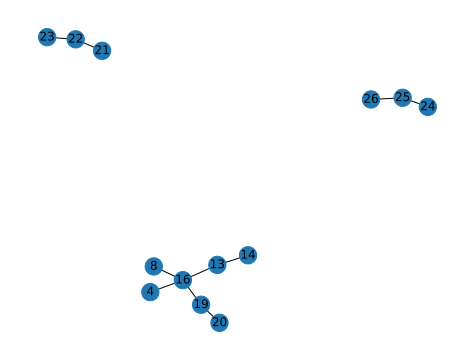

fusion  (4, 24)  success
fusion failure  4 24
rebuilding vertex 4
connected components for neighbor 16 : {8, 13, 14, 16, 19, 20}
set initial ghz as  (4, 16, 30) fusing the last with neighbor 16
rebuilding vertex 24
connected components for neighbor 25 : {25, 26}
set initial ghz as  (24, 25, 26)
vertex map: {4: 29, 16: 28, 24: 32, 25: 31, 26: 30}
in dfs for graph with nodes [8, 13, 14, 16, 19, 20, 21, 22, 23, 27, 28, 29, 30, 31, 32] fusion order [(5, 6), (11, 12), (17, 18), (16, 27), (29, 32), (23, 30)]


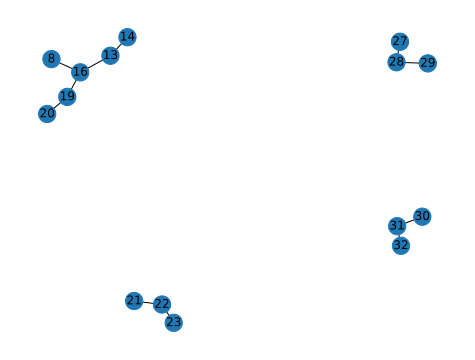

fusion  (16, 27)  success
fusion failure  16 27
rebuilding vertex 16
connected components for neighbor 19 : {19, 20}
set initial ghz as  (16, 19, 20)
add singular vertex 8
rebuilding vertex 27
connected components for neighbor 28 : {28, 29}
set initial ghz as  (27, 28, 29)
vertex map: {16: 43, 19: 34, 20: 33, 13: 40, 14: 41, 8: 44, 27: 47, 28: 46, 29: 45}
fusion failure  7 9
rebuilding vertex 7
connected components for neighbor 8 : {8}
connected components for neighbor 4 : {3, 4}
set initial ghz as  (7, 4, 3)
add singular vertex 8
rebuilding vertex 9
connected components for neighbor 16 : {13, 14, 16, 19, 20}
set initial ghz as  (9, 16, 57) fusing the last with neighbor 16
vertex map: {7: 52, 4: 49, 3: 48, 8: 53, 9: 56, 16: 55}
in dfs for graph with nodes [0, 1, 2, 13, 14, 16, 19, 20, 48, 49, 50, 51, 52, 53, 54, 55, 56] fusion order [(5, 6), (11, 12), (17, 18), (50, 51), (16, 54), (52, 56), (2, 48)]


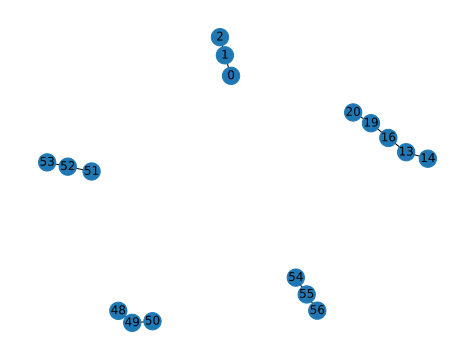

fusion  (50, 51)  success
in dfs for graph with nodes [0, 1, 2, 13, 14, 16, 19, 20, 48, 49, 52, 53, 54, 55, 56] fusion order [(5, 6), (11, 12), (17, 18), (50, 51), (16, 54), (52, 56), (2, 48)]


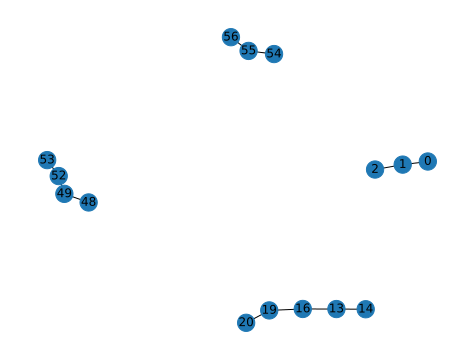

fusion  (16, 54)  success
fusion failure  16 54
rebuilding vertex 16
connected components for neighbor 19 : {19, 20}
set initial ghz as  (16, 19, 20)
rebuilding vertex 54
connected components for neighbor 55 : {56, 55}
set initial ghz as  (54, 55, 56)
vertex map: {16: 61, 19: 58, 20: 57, 13: 64, 14: 65, 54: 68, 55: 67, 56: 66}
fusion failure  50 51
rebuilding vertex 50
connected components for neighbor 49 : {48, 49}
set initial ghz as  (50, 49, 48)
rebuilding vertex 51
connected components for neighbor 52 : {52, 53}
set initial ghz as  (51, 52, 53)
vertex map: {50: 71, 49: 70, 48: 69, 51: 74, 52: 73, 53: 72}
fusion failure  10 15
rebuilding vertex 10
connected components for neighbor 9 : {9}
connected components for neighbor 13 : {13, 14}
set initial ghz as  (10, 13, 14)
add singular vertex 9
rebuilding vertex 15
connected components for neighbor 16 : {16, 19, 20}
set initial ghz as  (15, 16, 84) fusing the last with neighbor 16
vertex map: {10: 79, 13: 76, 14: 75, 9: 80, 15: 83, 16: 8

{0.5: 33.33333332696848,
 0.66: 14.790392343750135,
 0.75: 10.811016142632312,
 0.85: 8.226027897315271,
 1: 5.999999995929509}

In [40]:
get_fp_times([ (5, 6), (11, 12), (17, 18),(10, 15), (7, 9), (2, 3)], int(current_optimal_tree.circuit.m/2), [0.5,0.66,0.75,0.85,1], True)

In [18]:
expand = [(vdsp_tree.head,0)]
while expand:
    vertex,depth = expand.pop()
    print(" "*(4*(depth-1))+("|---" if depth > 0 else "")+str(vertex.value))
    for child in vertex.children:
        expand.append((child, depth+1))

0
|---6
    |---5
        |---2
    |---3
        |---4
    |---1


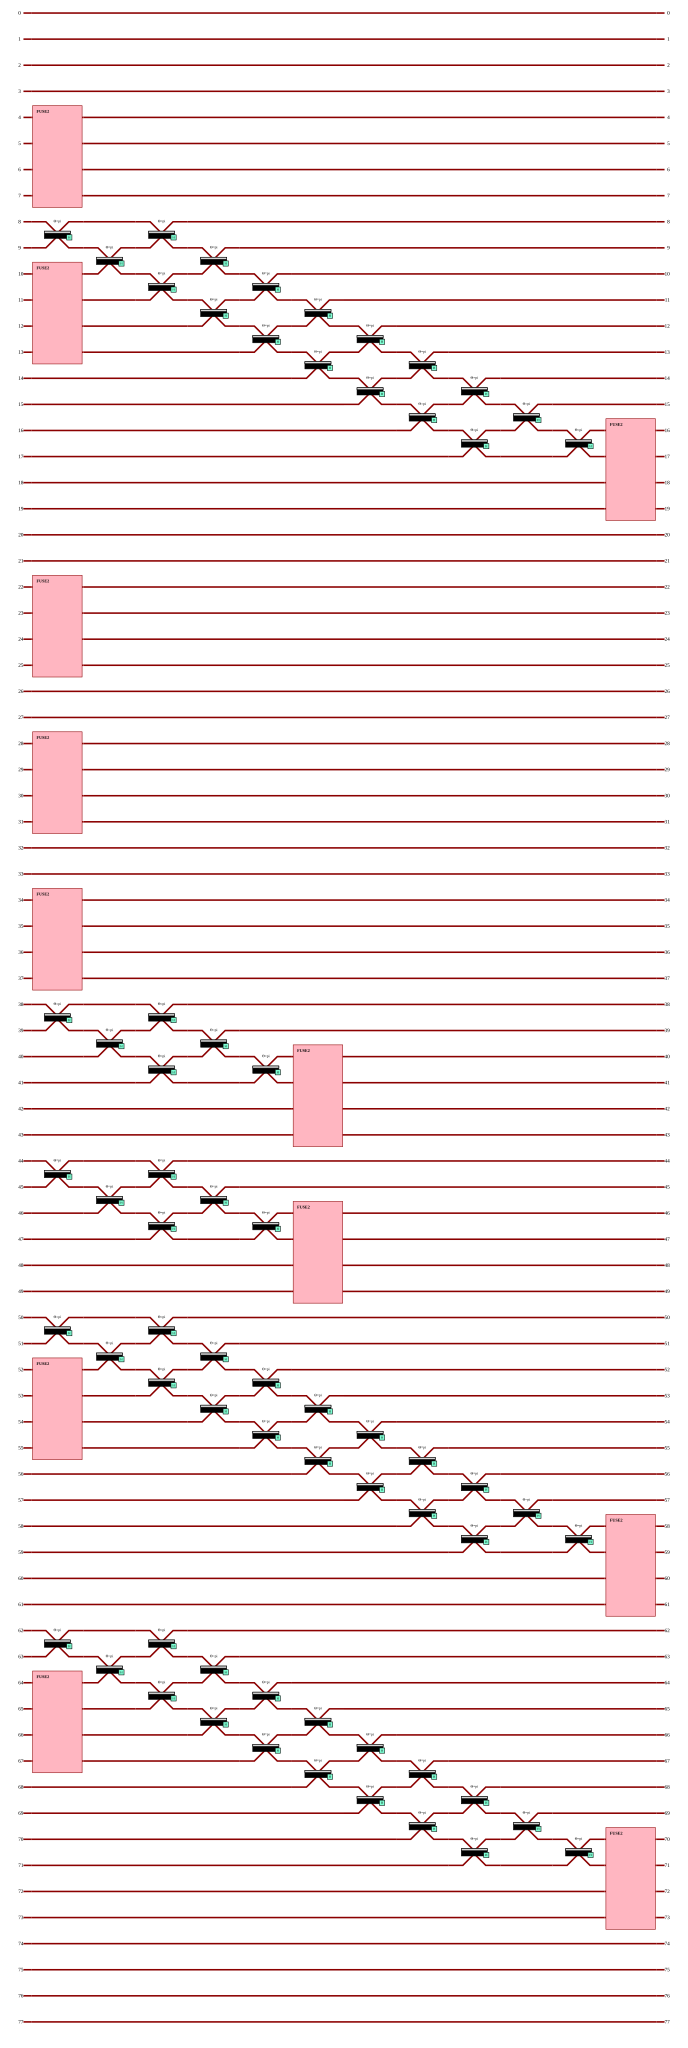

In [9]:
pcvl.pdisplay(current_optimal_tree.circuit)

In [20]:
def get_fusion_order(circuit):
    mode_count = [0]*circuit.m
    pos_map = {i: i for i in range(circuit.m)} #end_mode -> start_mode
    fusion_component_depth = {} #start_modes -> depth
    for component in circuit._components:
#         print("gate",component[1].name,"at",component[0])
        if len(component[0]) > 2 and component[1].name != 'Fuse2':
            # skip annoying identity gate at beginning
            continue
        elif component[1].name == 'Fuse2':
            start_modes = tuple([pos_map[m] for m in component[0]])
            fusion_component_depth[start_modes] = max([mode_count[m] for m in component[0]])
        else:
            mode0, mode1 = component[0]
            outer_loop = max(mode_count[mode0],mode_count[mode1])
            mode_count[mode0] = outer_loop + 1
            mode_count[mode1] = outer_loop
            
            temp = pos_map[mode0]
            pos_map[mode0] = pos_map[mode1]
            pos_map[mode1] = temp
    
    initial_modes_map = get_mode_pos_map(circuit)
    reduced_fusion_list = [(v,(k[0],k[2])) for k,v in fusion_component_depth.items()]
    return [(int(m[0]/2),int(m[1]/2)) for l,m in sorted(reduced_fusion_list)]

print(get_fusion_order(current_optimal_tree.circuit))

{0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 10, 9: 11, 10: 12, 11: 13, 12: 14, 13: 15, 14: 16, 15: 17, 16: 8, 17: 9, 18: 18, 19: 19, 20: 20, 21: 21, 22: 22, 23: 23, 24: 24, 25: 25, 26: 26, 27: 27, 28: 28, 29: 29, 30: 30, 31: 31, 32: 32, 33: 33, 34: 34, 35: 35, 36: 36, 37: 37, 38: 40, 39: 41, 40: 38, 41: 39, 42: 42, 43: 43, 44: 46, 45: 47, 46: 44, 47: 45, 48: 48, 49: 49, 50: 52, 51: 53, 52: 54, 53: 55, 54: 56, 55: 57, 56: 58, 57: 59, 58: 50, 59: 51, 60: 60, 61: 61, 62: 64, 63: 65, 64: 66, 65: 67, 66: 68, 67: 69, 68: 70, 69: 71, 70: 62, 71: 63, 72: 72, 73: 73, 74: 74, 75: 75, 76: 76, 77: 77}
[(0, (4, 6)), (0, (10, 12)), (2, (8, 18)), (0, (22, 24)), (0, (28, 30)), (0, (34, 36)), (2, (38, 42)), (2, (44, 48)), (0, (52, 54)), (2, (50, 60)), (0, (64, 66)), (2, (62, 72))]
[(2, 3), (5, 6), (11, 12), (14, 15), (17, 18), (26, 27), (32, 33), (4, 9), (19, 21), (22, 24), (25, 30), (31, 36)]


In [20]:
current_optimal_tree.vertex_pos_map

{0: 20, 11: 8, 6: 22}

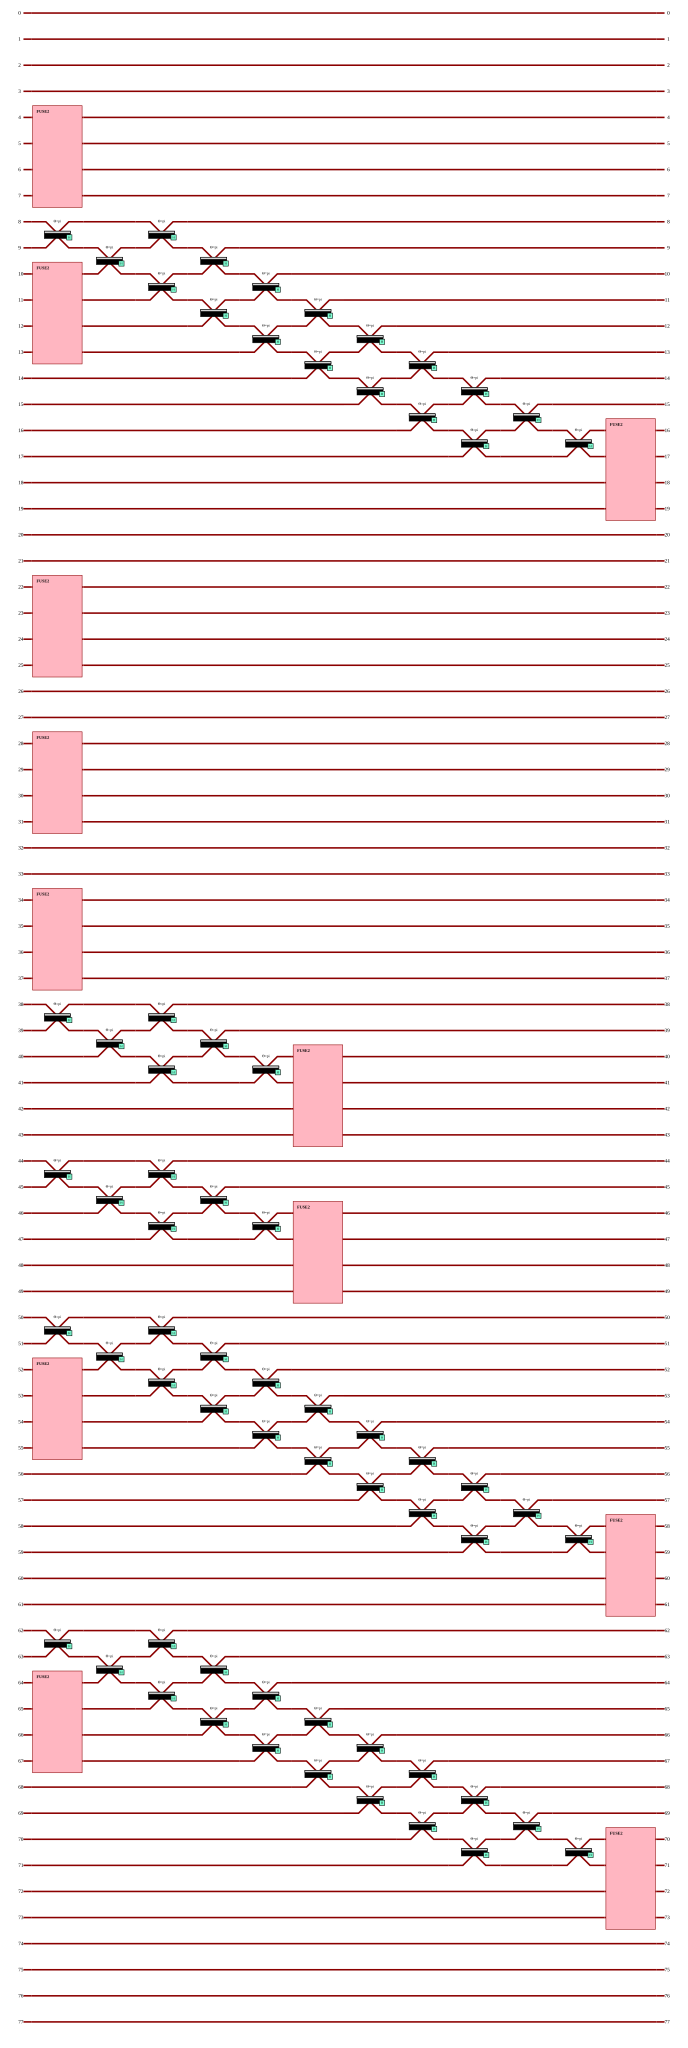

In [17]:
pcvl.pdisplay(current_optimal_tree.circuit)

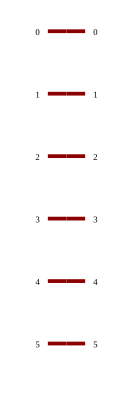

In [18]:
newc =  pcvl.Circuit(6)
newc2 = pcvl.Circuit(2)
newc.add(0,newc2,merge=True)
pcvl.pdisplay(newc)

In [12]:
vdsp_tree.head.value

0